<a href="https://colab.research.google.com/github/diabateyoussouf/Daily-Data-Science/blob/main/dailly_06_dataset_credit_card_fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Défi 06 : Détection d'Anomalies et Segmentation Non Supervisée

L'objectif de ce projet est d'identifier des comportements marginaux ou frauduleux au sein d'un jeu de données de transactions par carte bancaire, en utilisant des algorithmes d'apprentissage non supervisé.

### Dataset Suggéré
* **Source :** Credit Card Fraud Detection (disponible sur Kaggle ou via `sklearn.datasets`).
* **Particularité :** Les données ont été transformées via une ACP (Analyse en Composantes Principales) pour des raisons de confidentialité (colonnes V1 à V28), accompagnées du montant de la transaction.

###  Objectifs Scientifiques du Défi :
1. **Traitement du Déséquilibre :** Comprendre comment gérer un jeu de données où les anomalies représentent moins de 0.5% des lignes.
2. **Modélisation Non Supervisée :** Isoler les points aberrants sans utiliser les étiquettes durant la phase d'entraînement.
3. **Évaluation Métrique Spécifique :** Utiliser le score F1 et la matrice de confusion plutôt que l'Accuracy (qui serait faussement excellente à 99%).

In [1]:

import os
from google.colab import files

# Importation du fichier kaggle.json
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print(" Sélectionne le fichier 'kaggle.json' téléchargé depuis ton compte Kaggle :")
    uploaded = files.upload()

    # Configuration du dossier Kaggle
    os.makedirs('/root/.kaggle/', exist_ok=True)
    os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Téléchargement du dataset officiel de cartes bancaires
print("⏳ Téléchargement du dataset creditcardfraud...")
os.system('kaggle datasets download -d mlg-ulb/creditcardfraud')

# Dézippage des données
print("📦 Extraction du fichier ZIP...")
os.system('unzip -o creditcardfraud.zip')
print("✅ Dataset prêt à l'emploi !")

 Sélectionne le fichier 'kaggle.json' téléchargé depuis ton compte Kaggle :


Saving kaggle.json to kaggle.json
⏳ Téléchargement du dataset creditcardfraud...
📦 Extraction du fichier ZIP...
✅ Dataset prêt à l'emploi !


# **Importation des bibliothèques**

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# **Exploration du dataset**

In [3]:
df = pd.read_csv("/content/creditcard.csv")

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [19]:
df.shape

(284807, 31)

# **1. Traitement du Déséquilibre**

In [9]:
df['Class'].unique()

array([0, 1])

<Axes: ylabel='count'>

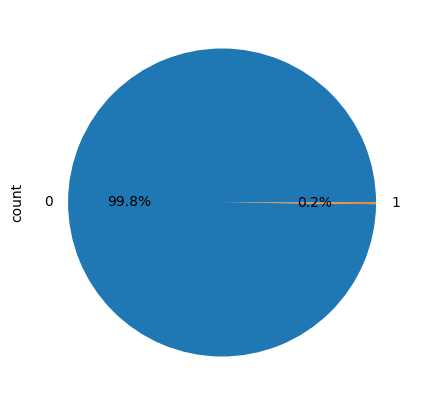

In [10]:
df['Class'].value_counts().plot.pie(figsize=(5,5), autopct='%1.1f%%')

Le dataset contient 0.2% de classe fraude et 99.8% de clausse No fraude. Extrème déséquilibre entre les classes.

# Les outliers

**Amount**

In [23]:
# Pour Amount
# 1er quartile
Q1 = df['Amount'].quantile(0.25)
# 3eme quartile
Q3 = df['Amount'].quantile(0.75)
# Interquartiles
IQR = Q3 - Q1
# Définition des seuils limites
borne_inferieure = Q1 - 1.5 * IQR
borne_superieure = Q3 + 1.5 * IQR

# Identification des valeurs aberrantes
outliers = df[(df['Amount'] < borne_inferieure) | (df['Amount'] > borne_superieure)]


In [24]:
print(f"  BILAN MATHÉMATIQUE DE LA COLONNE 'AMOUNT'")
print(f"- Premier Quartile (Q1) : {Q1:.2f} $")
print(f"- Troisième Quartile (Q3) : {Q3:.2f} $")
print(f"- Écart Interquartile (IQR) : {IQR:.2f} $")
print(f" Seuil maximal autorisé (Borne Supérieure) : {borne_superieure:.2f} $")
print(f"\nNombre total de valeurs aberrantes trouvées : {outliers.shape[0]} lignes")
print(f"Pourcentage du dataset que cela représente : {(outliers.shape[0] / df.shape[0]) * 100:.2f} %")

  BILAN MATHÉMATIQUE DE LA COLONNE 'AMOUNT'
- Premier Quartile (Q1) : 5.60 $
- Troisième Quartile (Q3) : 77.16 $
- Écart Interquartile (IQR) : 71.56 $
 Seuil maximal autorisé (Borne Supérieure) : 184.51 $

Nombre total de valeurs aberrantes trouvées : 31904 lignes
Pourcentage du dataset que cela représente : 11.20 %


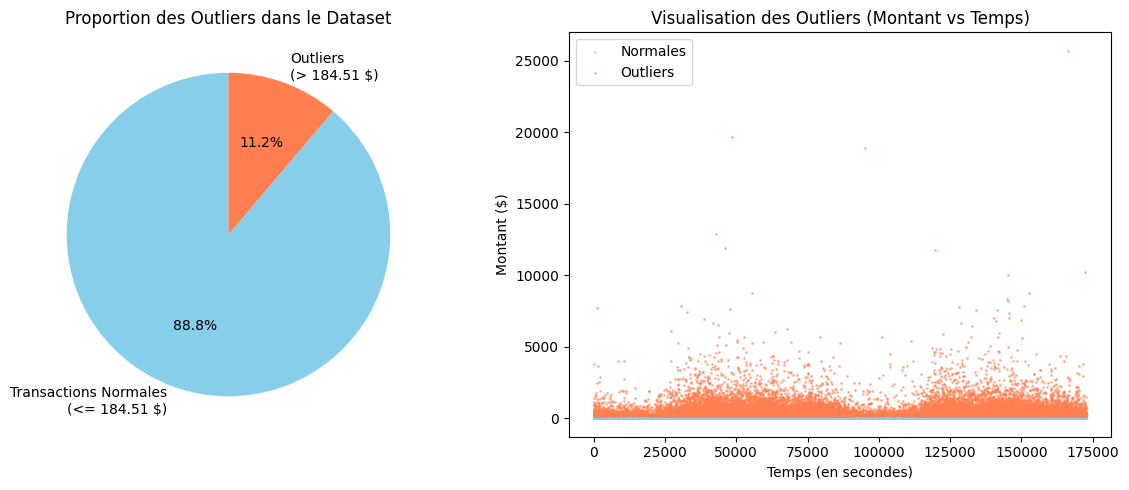

In [25]:
outliers_df = df[df['Amount'] > borne_superieure]
non_outliers_df = df[df['Amount'] <= borne_superieure]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
Tailles = [len(non_outliers_df), len(outliers_df)]
Labels = ['Transactions Normales\n(<= 184.51 $)', 'Outliers\n(> 184.51 $)']
plt.pie(Tailles, labels=Labels, autopct='%1.1f%%', colors=['skyblue', 'coral'], startangle=90)
plt.title("Proportion des Outliers dans le Dataset")

plt.subplot(1, 2, 2)
plt.scatter(non_outliers_df['Time'], non_outliers_df['Amount'], alpha=0.5, label='Normales', color='skyblue', s=1)
plt.scatter(outliers_df['Time'], outliers_df['Amount'], alpha=0.5, label='Outliers', color='coral', s=1)
plt.title("Visualisation des Outliers (Montant vs Temps)")
plt.xlabel("Temps (en secondes)")
plt.ylabel("Montant ($)")
plt.legend()

plt.tight_layout()
plt.show()

**Time**

In [26]:
Q1_t = df['Time'].quantile(0.25)
Q3_t = df['Time'].quantile(0.75)
IQR_t = Q3_t - Q1_t
borne_inferieure = Q1_t - 1.5 * IQR_t
borne_superieure = Q3_t + 1.5 * IQR_t

outliers = df[(df['Time'] < borne_inferieure) | (df['Time'] > borne_superieure)]

In [27]:
print(f"  BILAN MATHÉMATIQUE DE LA COLONNE 'TIME'")
print(f"- Premier Quartile (Q1) : {Q1_t:.2f} secondes")
print(f"- Troisième Quartile (Q3) : {Q3_t:.2f} secondes")
print(f"- Écart Interquartile (IQR) : {IQR_t:.2f} secondes")
print(f" Seuil maximal autorisé (Borne Supérieure) : {borne_superieure:.2f} secondes")
print(f"\nNombre total de valeurs aberrantes trouvées : {outliers.shape[0]} lignes")
print(f"Pourcentage du dataset que cela représente : {(outliers.shape[0] / df.shape[0]) * 100:.2f} %")

  BILAN MATHÉMATIQUE DE LA COLONNE 'TIME'
- Premier Quartile (Q1) : 54201.50 secondes
- Troisième Quartile (Q3) : 139320.50 secondes
- Écart Interquartile (IQR) : 85119.00 secondes
 Seuil maximal autorisé (Borne Supérieure) : 266999.00 secondes

Nombre total de valeurs aberrantes trouvées : 0 lignes
Pourcentage du dataset que cela représente : 0.00 %


In [29]:
# Nombre total de fraudes dans tout le dataset
total_fraudes = df[df['Class'] == 1].shape[0]

# Nombre de fraudes qui sont aussi des outliers de montant
fraudes_dans_outliers = df[(df['Class'] == 1) & (df['Amount'] > borne_superieure)].shape[0]

print(f"Nombre total de fraudes recensées : {total_fraudes}")
print(f"Nombre de fraudes ayant un montant 'aberrant' (> 184.51 $) : {fraudes_dans_outliers}")
print(f"Pourcentage de fraudes cachées dans les outliers : {(fraudes_dans_outliers / total_fraudes) * 100:.2f} %")

Nombre total de fraudes recensées : 492
Nombre de fraudes ayant un montant 'aberrant' (> 184.51 $) : 0
Pourcentage de fraudes cachées dans les outliers : 0.00 %


Auccunesvaleurs outliers sont frauduleuses

# **Train Split**

In [30]:

from sklearn.model_selection import train_test_split

# Séparation des caractéristiques (X) et de la cible (y)
X = df.drop(columns=['Class'])
y = df['Class']

# Découpage (80% entraînement / 20% validation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # pour garder la même proportion de fraudes (0.17%) des deux côtés
)

In [31]:
print(f"Données splittées avec succès.")
print(f" - Lignes d'entraînement (X_train) : {X_train.shape[0]}")
print(f"-  Lignes de test (X_test) : {X_test.shape[0]}")

Données splittées avec succès.
 - Lignes d'entraînement (X_train) : 227845
-  Lignes de test (X_test) : 56962


# **NORMALISATION ROBUSTE**

In [32]:
from sklearn.preprocessing import RobustScaler

# Instanciation du scaler
scaler = RobustScaler()

# Liste des colonnes à normaliser (celles qui ne sont pas issues de l'ACP)
colonnes_a_scaler = ['Time', 'Amount']

# Fit + Transform sur le TRAIN (Calcule la médiane/IQR du Train et applique)
X_train[colonnes_a_scaler] = scaler.fit_transform(X_train[colonnes_a_scaler])

# Transform uniquement sur le TEST (Utilise les calculs du Train, pas de triche !)
X_test[colonnes_a_scaler] = scaler.transform(X_test[colonnes_a_scaler])

print(" Normalisation terminée.")
print("\nVérification des échelles (Moyenne / Min / Max) sur X_train['Amount'] :")
print(X_train['Amount'].describe()[['mean', 'min', 'max']])

 Normalisation terminée.

Vérification des échelles (Moyenne / Min / Max) sur X_train['Amount'] :
mean      0.921034
min      -0.306193
max     357.260404
Name: Amount, dtype: float64


# **Entraînement du modèle**

In [33]:
from sklearn.ensemble import IsolationForest
import numpy as np

print("Entraînement de l'Isolation Forest en cours...")

# Configuration du modèle
# contamination=0.0017 correspond à la proportion réelle de fraudes (0.17%)
# On dit à l'algorithme d'isoler les 0.17% de points les plus marginaux du dataset.
model_iforest = IsolationForest(contamination=0.0017, random_state=42, n_jobs=-1)

# Entraînement (Sans les étiquettes !)
model_iforest.fit(X_train)

# Prédiction sur le jeu de test
# L'Isolation Forest renvoie -1 pour une anomalie et 1 pour un point normal
predictions_brutes = model_iforest.predict(X_test)

# Conversion au format standard (1 = Fraude, 0 = Normal)
y_pred_iforest = np.where(predictions_brutes == -1, 1, 0)

print("Modèle entraîné et prédictions générées sur le jeu de test.")

Entraînement de l'Isolation Forest en cours...
Modèle entraîné et prédictions générées sur le jeu de test.


# Modèle Robust Scaller Resultats

 MATRICE DE CONFUSION 
Transactions normales correctement classées (Vrais Négatifs) : 56791
Clients honnêtes suspectés à tort (Faux Positifs)           : 73
Fraudes manquées par le modèle (Faux Négatifs)             : 65
Fraudes correctement interceptées (Vrais Positifs)         : 33

RAPPORT DE PERFORMANCE
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     56864
  Fraude (1)       0.31      0.34      0.32        98

    accuracy                           1.00     56962
   macro avg       0.66      0.67      0.66     56962
weighted avg       1.00      1.00      1.00     56962



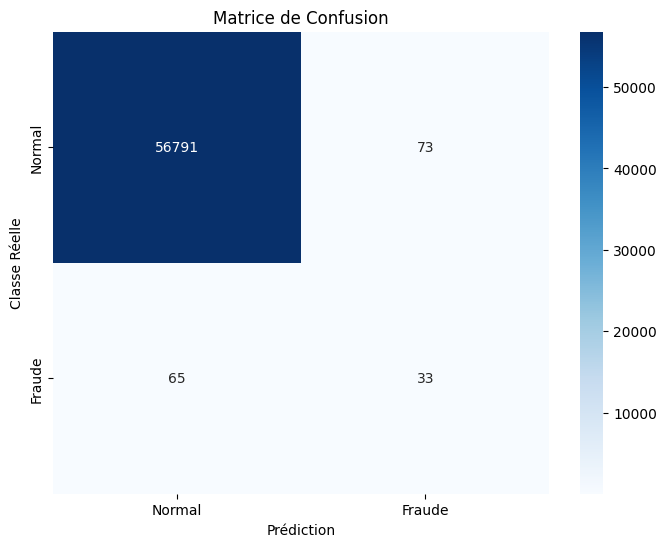

In [35]:
from sklearn.metrics import classification_report, confusion_matrix

print(" MATRICE DE CONFUSION ")
cm = confusion_matrix(y_test, y_pred_iforest)

print(f"Transactions normales correctement classées (Vrais Négatifs) : {cm[0][0]}")
print(f"Clients honnêtes suspectés à tort (Faux Positifs)           : {cm[0][1]}")
print(f"Fraudes manquées par le modèle (Faux Négatifs)             : {cm[1][0]}")
print(f"Fraudes correctement interceptées (Vrais Positifs)         : {cm[1][1]}")

print("\nRAPPORT DE PERFORMANCE")
print(classification_report(y_test, y_pred_iforest, target_names=['Normal (0)', 'Fraude (1)']))
plt.figure(figsize=(8, 6))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraude'], yticklabels=['Normal', 'Fraude'])
plt.xlabel('Prédiction')
plt.ylabel('Classe Réelle')
plt.title('Matrice de Confusion')
plt.show()

# XGBOOST

In [36]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Calcul mathématique du poids pour équilibrer le déséquilibre
classe_0 = (y_train == 0).sum()
classe_1 = (y_train == 1).sum()
poids_ajuste = classe_0 / classe_1

print(f"⚖️ Ratio de poids calculé pour XGBoost : {poids_ajuste:.2f}")

# Configuration et entraînement du modèle
# On utilise le poids calculé pour forcer le modèle à traquer la classe 1
model_xgb = XGBClassifier(scale_pos_weight=poids_ajuste, random_state=42, n_jobs=-1)
model_xgb.fit(X_train, y_train)
# Prédiction
y_pred_xgb = model_xgb.predict(X_test)

print("Entraînement XGBoost terminé.")

⚖️ Ratio de poids calculé pour XGBoost : 577.29
Entraînement XGBoost terminé.


In [37]:
print(" MATRICE DE CONFUSION XGBOOST ")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"Transactions normales correctement classées : {cm_xgb[0][0]}")
print(f"Clients honnêtes suspectés à tort (Faux Positifs) : {cm_xgb[0][1]}")
print(f"Fraudes manquées par le modèle (Faux Négatifs)   : {cm_xgb[1][0]}")
print(f"Fraudes correctement interceptées (Vrais Positifs) : {cm_xgb[1][1]}")

print("\n RAPPORT DE PERFORMANCE XGBOOST ")
print(classification_report(y_test, y_pred_xgb, target_names=['Normal (0)', 'Fraude (1)']))

 MATRICE DE CONFUSION XGBOOST 
Transactions normales correctement classées : 56853
Clients honnêtes suspectés à tort (Faux Positifs) : 11
Fraudes manquées par le modèle (Faux Négatifs)   : 16
Fraudes correctement interceptées (Vrais Positifs) : 82

 RAPPORT DE PERFORMANCE XGBOOST 
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     56864
  Fraude (1)       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



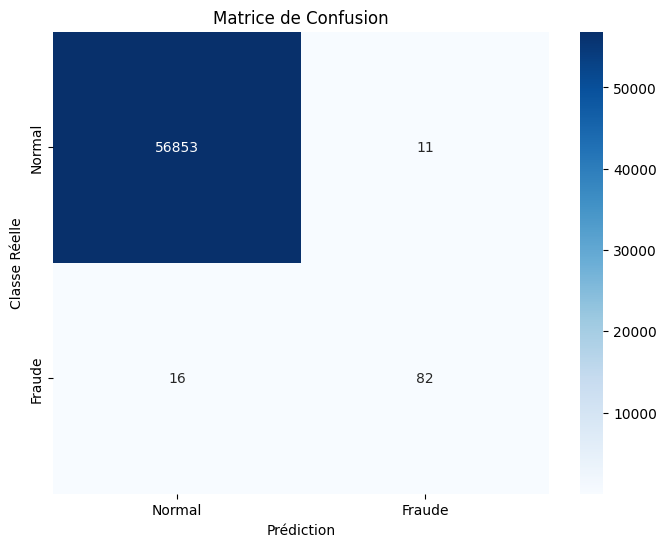

In [39]:
plt.figure(figsize=(8, 6))
sn.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraude'], yticklabels=['Normal', 'Fraude'])
plt.xlabel('Prédiction')
plt.ylabel('Classe Réelle')
plt.title('Matrice de Confusion')
plt.show()

# **Réduction de dimension avec l'ACP et Visualisation**

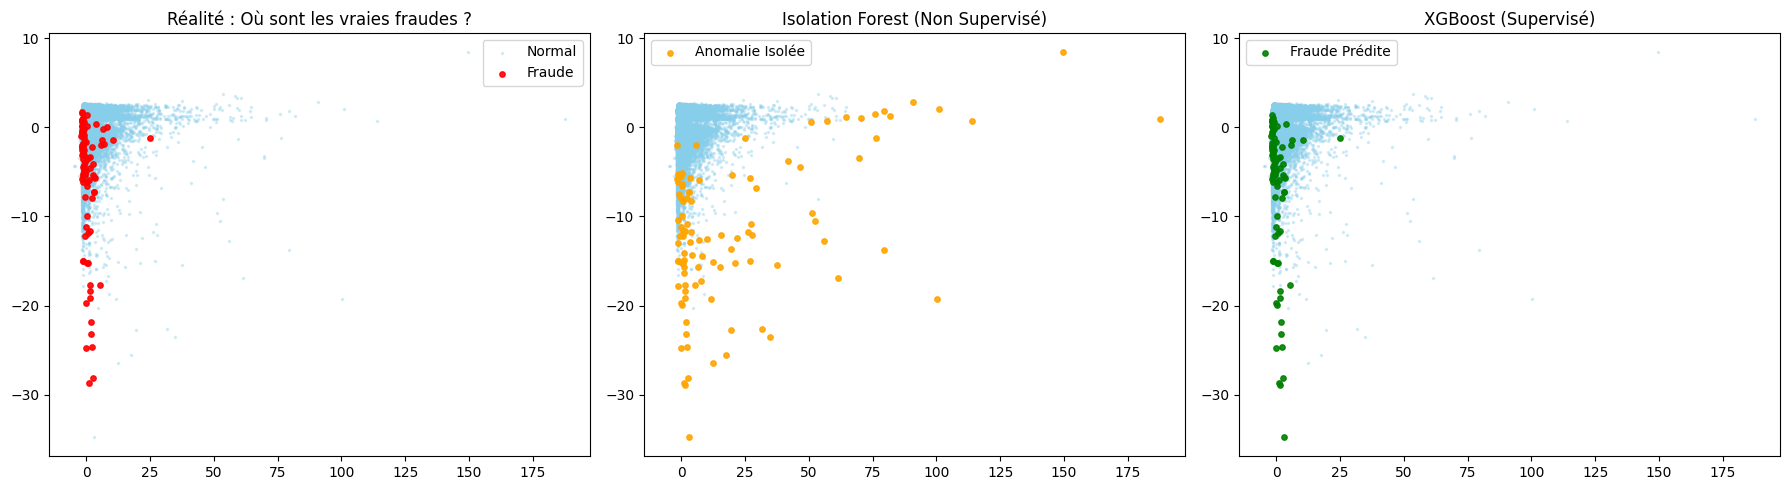

In [41]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# On applique l'ACP pour passer de 30 dimensions à 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test)

# Création un DataFrame temporaire pour faciliter le plotting
df_visu = pd.DataFrame(X_test_pca, columns=['Composante 1', 'Composante 2'])
df_visu['Vraie_Classe'] = y_test.values
df_visu['Pred_IForest'] = y_pred_iforest
df_visu['Pred_XGB'] = y_pred_xgb

# Affichage des graphiques
plt.figure(figsize=(18, 5))

# La Réalité du terrain
plt.subplot(1, 3, 1)
plt.scatter(df_visu[df_visu['Vraie_Classe'] == 0]['Composante 1'], df_visu[df_visu['Vraie_Classe'] == 0]['Composante 2'], alpha=0.3, label='Normal', color='skyblue', s=2)
plt.scatter(df_visu[df_visu['Vraie_Classe'] == 1]['Composante 1'], df_visu[df_visu['Vraie_Classe'] == 1]['Composante 2'], alpha=0.9, label='Fraude', color='red', s=15)
plt.title("Réalité : Où sont les vraies fraudes ?")
plt.legend()

# Ce que l'Isolation Forest (Non Supervisé) a vu
plt.subplot(1, 3, 2)
plt.scatter(df_visu[df_visu['Pred_IForest'] == 0]['Composante 1'], df_visu[df_visu['Pred_IForest'] == 0]['Composante 2'], alpha=0.3, color='skyblue', s=2)
plt.scatter(df_visu[df_visu['Pred_IForest'] == 1]['Composante 1'], df_visu[df_visu['Pred_IForest'] == 1]['Composante 2'], alpha=0.9, label='Anomalie Isolée', color='orange', s=15)
plt.title("Isolation Forest (Non Supervisé)")
plt.legend()

#  Ce que XGBoost (Supervisé) a vu
plt.subplot(1, 3, 3)
plt.scatter(df_visu[df_visu['Pred_XGB'] == 0]['Composante 1'], df_visu[df_visu['Pred_XGB'] == 0]['Composante 2'], alpha=0.3, color='skyblue', s=2)
plt.scatter(df_visu[df_visu['Pred_XGB'] == 1]['Composante 1'], df_visu[df_visu['Pred_XGB'] == 1]['Composante 2'], alpha=0.9, label='Fraude Prédite', color='green', s=15)
plt.title("XGBoost (Supervisé)")
plt.legend()

plt.tight_layout()
plt.show()